In [6]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import tight_layout
from statsmodels.sandbox.distributions.genpareto import meanexcess

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2025_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_h_kxylem"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0']
vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
#index_to_drop = df[(df['sid']==2)|(df['sid']==2)].index
#df.drop(index_to_drop, inplace=True)
#df = df[df['RMSE_MAX'] < 1.0]
df_grp = df.groupby(['id'])[vars_all_ex].mean()
dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
#df_norm = (dv - dv.mean()) / dv.std()
df_norm = dv
df_norm['sid'] = df['sid']
df_norm['RMSE_MAX'] = df['RMSE_MAX']
df_norm.shape

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_99959/300559384.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_99959/300559384.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_norm['sid'] = df['sid']
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_99959/300559384.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

(113264, 20)

In [8]:
df_grp

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark,RMSE_MAX
id,,,,,,,,,,,,,,,,,,,
0,-2.038829,3.530689,3572.643473,93.379167,0.000738,0.740835,-3.836041,-5.035124,0.001192,2.322512,2.493678e-07,-2.728633,0.919835,0.273935,0.322208,10.728318,-0.508448,0.004404,1.113523
1,-2.009891,2.840201,4002.672379,47.954968,0.000671,0.126754,-3.853373,-4.915026,0.000987,2.167791,6.184070e-07,-2.989336,0.928237,0.265450,0.720682,6.640732,-0.555857,0.004099,1.048951
2,-2.085043,2.954522,3042.724959,81.877261,0.000570,0.063098,-3.759063,-5.098023,0.001105,1.902964,5.366304e-07,-3.069775,0.933764,0.273353,0.286646,11.053595,-0.573072,0.003362,1.206319
3,-2.080382,2.884287,5994.732803,78.571145,0.000740,0.252200,-3.642972,-4.793574,0.002469,1.580137,5.962994e-07,-2.980594,0.941372,0.270175,0.251355,11.777070,-0.505624,0.007483,1.199434
4,-2.055395,3.841746,5297.141750,41.723534,0.000722,0.163599,-3.853309,-5.000675,0.001616,1.397446,4.851289e-07,-2.972329,0.925124,0.261471,0.524892,8.121354,-0.421565,0.006934,0.952436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28311,-2.083779,3.053170,5335.856352,50.194247,0.000659,0.360753,-3.729278,-4.836304,0.001350,1.854202,3.850005e-07,-3.031280,0.933052,0.259069,0.173844,10.104094,-0.564220,0.004381,1.256921
28312,-2.073989,3.031731,3942.675541,71.057587,0.000734,0.259540,-3.755455,-4.859175,0.001127,1.892676,5.735944e-07,-3.228980,0.936596,0.261442,0.320077,8.573186,-0.588877,0.004610,1.081576
28313,-2.016125,4.063187,5397.648697,57.843016,0.000769,1.038079,-3.748546,-4.837192,0.002041,2.414070,5.291844e-07,-3.253095,0.924895,0.260353,0.497000,9.732264,-0.439157,0.006818,1.024515


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

In [10]:
df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_99959/4048080806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_norm['alive'] = 1


In [11]:
imps = []

for i in range(0, 2):
    
    if i == 0:
        svars = vars_all
    else:
        svars = vars_plant
    X_train, X_test, y_train, y_test = train_test_split(df_norm[svars], df_norm['alive'], test_size=0.3, random_state=42)
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10, 
        random_state=2909, class_weight='balanced')
    rf.fit(X_train, y_train)
    print(rf.score(X_train, y_train))
    print(rf.score(X_test, y_test))

    perm = permutation_importance(
        rf,
        X_test,  # we use the test set
        y_test,
        scoring="accuracy",  # we can use any metric
        n_repeats=50,
        random_state=42,
    )
    importance = pd.DataFrame(
        {"importance_mean": perm["importances_mean"],
         "importance_std": perm["importances_std"]},
        index=rf.feature_names_in_)
    importance.sort_values(by="importance_mean",
                           ascending=False, inplace=True
                           )
    imps.append(importance)


0.9998486453761163
0.9996468510888759
0.7444755562282428
0.7326074161271336


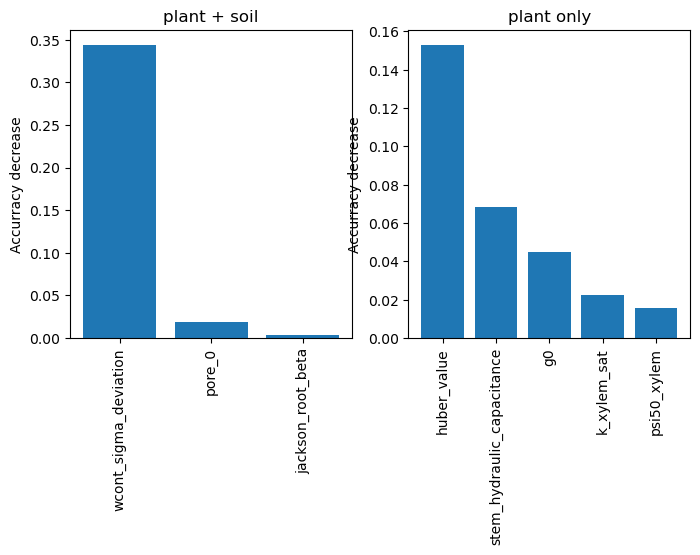

In [12]:
var_labs_size = [3,5]
title_labs  = ["plant + soil", "plant only"]
fig = plt.figure(figsize=(8, 4))
for i in range(0, len(imps)):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps[i][0:var_labs_size[i]].index,imps[i][0:var_labs_size[i]]['importance_mean'])
    ax.set_title(title_labs[i])
    ax.set_ylabel("Accurracy decrease")
    ax.tick_params(axis='x', labelrotation=90)
plt.show()

In [13]:
label_dict  = {}
label_dict['huber_value'] = r"Huber"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['k_xylem_sat'] = r"$k_\mathrm{xyl, sat}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_close_50'] = r"$\psi_{close, 50}$"

In [14]:
labs = imps[0][0:var_labs_size[i]].index.tolist()

In [15]:
labs_tex = [label_dict[lab] for lab in labs]

KeyError: 'psi_leaf_50_close'

In [25]:
labs_tex

['$\\sigma_\\mathrm{wcont}$', '$\\xi$', '$\\mathrm{Root}_\\beta$']

In [13]:
#labs_all =[r"$\sigma_\mathrm{wcont}$", r"Root $\beta$",r"$g_1$"]

#labs_plant =[ r"Huber", r"$g_0$",r"$\Gamma_\mathrm{Stem}$",r"$k_\mathrm{xyl, sat}$", r"$\psi_{50}$",r"$\Gamma_\mathrm{Leaf}$"]

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_72625/198641375.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_tex)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_72625/198641375.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_tex)


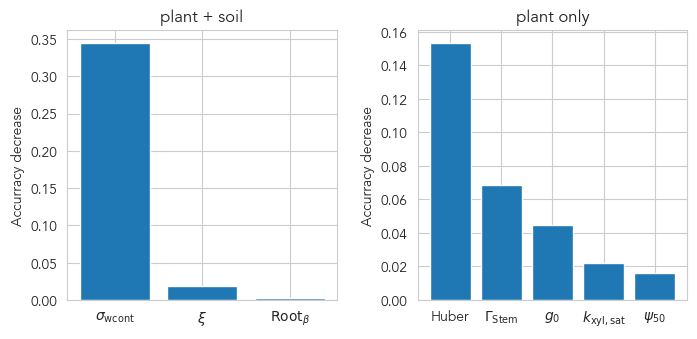

In [29]:
plt.rcParams["font.family"] = "Avenir"
var_labs_size = [3,5]
title_labs  = ["plant + soil", "plant only"]
fig = plt.figure(figsize=(8, 3.5))
for i in range(0, len(imps)):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps[i][0:var_labs_size[i]].index,imps[i][0:var_labs_size[i]]['importance_mean'])

    labs = imps[i][0:var_labs_size[i]].index.tolist()
    
    labs_tex = [label_dict[lab] for lab in labs]
    
    ax.set_xticklabels(labs_tex)

    ax.set_title(title_labs[i])
    ax.set_ylabel("Accurracy decrease")
plt.subplots_adjust(wspace=0.3)

plt.savefig(os.path.join(post_path, "F2_RF_classifier.png"), bbox_inches='tight', dpi=300)
plt.show()


In [16]:
imps_regress = []
from sklearn import metrics

for i in range(0, 2):
    if i == 0:
        dfs_norm = df_norm[df_norm['sid'] == 0]
    else:
        dfs_norm = df_norm[df_norm['sid'] > 0]
        
    X_train, X_test, y_train, y_test = train_test_split(dfs_norm[vars_all], dfs_norm['RMSE_MAX'], test_size=0.3, random_state=42)
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=15, 
        random_state=2909)
    
    rf.fit(X_train, y_train)
    
    print(rf.score(X_train, y_train))
    
    print('Root Mean Squared Error (RMSE) train:', metrics.root_mean_squared_error(y_train, rf.predict(X_train)))
    print('Root Mean Squared Error (RMSE) test:', metrics.root_mean_squared_error(y_test, rf.predict(X_test)))   


    perm = permutation_importance(
        rf,
        X_test,  # we use the test set
        y_test,
        scoring="neg_root_mean_squared_error",  # we can use any metric
        n_repeats=50,
        random_state=42
    )
    importance = pd.DataFrame(
        {"importance_mean": perm["importances_mean"],
         "importance_std": perm["importances_std"]},
        index=rf.feature_names_in_)
    importance.sort_values(by="importance_mean",
                           ascending=False, inplace=True
                           )
    imps_regress.append(importance)

0.9520919787304788
Root Mean Squared Error (RMSE) train: 0.026769497932334296
Root Mean Squared Error (RMSE) test: 0.06051142017975041
0.971008094461896
Root Mean Squared Error (RMSE) train: 0.020844551686628514
Root Mean Squared Error (RMSE) test: 0.03953210994785299


In [17]:
imps_regress[0]

,importance_mean,importance_std
stem_hydraulic_capacitance,0.082070,0.000944
huber_value,0.032543,0.000547
g_bark,0.020291,0.000351
g0,0.016951,0.000299
anet_max,0.014097,0.000326
k_xylem_sat,0.008278,0.000272
g1,0.000786,0.000057
d_50_close,0.000421,0.000056
leaf_hydraulic_capacitance,0.000328,0.000046
psi_leaf_50_close,0.000211,0.000041


In [18]:
imps_regress[1]

,importance_mean,importance_std
stem_hydraulic_capacitance,0.093247,0.000453
huber_value,0.048003,0.000390
g_bark,0.036242,0.000320
anet_max,0.018028,0.000263
g0,0.017967,0.000208
k_xylem_sat,0.016956,0.000206
wcont_sigma_deviation,0.014411,0.000239
psi88_xylem,0.010366,0.000186
pore_0,0.002815,0.000073
jackson_root_beta,0.002594,0.000184


In [19]:
label_dict  = {}
label_dict['huber_value'] = r"Huber"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['k_xylem_sat'] = r"$k_\mathrm{xyl, sat}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{Leaf, close}$"
label_dict['g_bark'] = r"$g_\mathrm{Stem}$"
label_dict['anet_max'] = r"$\mathrm{A_{max}}$"

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_99959/1992779515.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_tex)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_99959/1992779515.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_tex)


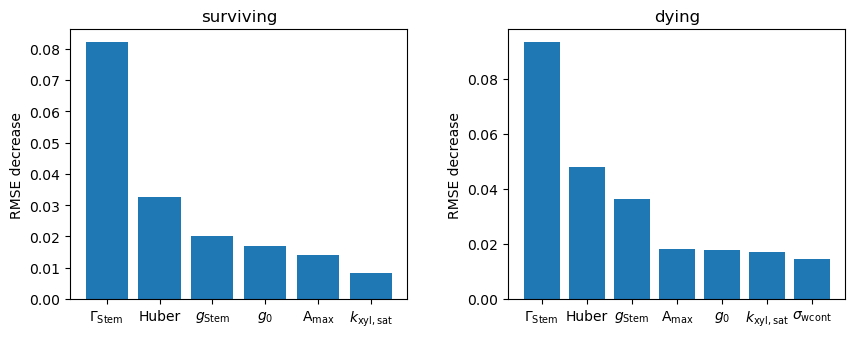

In [20]:
var_labs_size = [6, 7]

title_labs  = ["surviving", "dying"]
fig = plt.figure(figsize=(10, 3.5))
for i in range(0, 2):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps_regress[i][0:var_labs_size[i]].index,imps_regress[i][0:var_labs_size[i]]['importance_mean'])
    labs = imps_regress[i][0:var_labs_size[i]].index.tolist()
    
    labs_tex = [label_dict[lab] for lab in labs]
    
    ax.set_xticklabels(labs_tex)
    ax.set_title(title_labs[i])
    ax.set_ylabel("RMSE decrease")
plt.subplots_adjust(wspace=0.3)

plt.savefig(os.path.join(post_path, "F3_RF_regressor.png"), bbox_inches='tight', dpi=300)
plt.show()

In [21]:
imps_regress[1]

,importance_mean,importance_std
stem_hydraulic_capacitance,0.093247,0.000453
huber_value,0.048003,0.000390
g_bark,0.036242,0.000320
anet_max,0.018028,0.000263
g0,0.017967,0.000208
k_xylem_sat,0.016956,0.000206
wcont_sigma_deviation,0.014411,0.000239
psi88_xylem,0.010366,0.000186
pore_0,0.002815,0.000073
jackson_root_beta,0.002594,0.000184


In [22]:
labs = list(reversed([r"$g_{0}$", r"$k_\mathrm{xylem}$", r"$\Gamma_\mathrm{Stem}$", r"Huber"
                     , r"$\psi_{50}$", "Rest (2)"]))
shap.plots.beeswarm(shap_values[:,:], color="viridis", max_display=6, show = False, plot_size=[6,4])
ax = plt.gca()
ax.set_xlabel("better    <--      SHAP value (RMSE)    -->  worse")
ax.set_yticklabels(labs)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig(os.path.join(post_path, 'Figure_2_shap_values_plant_RMSE.png'), dpi=300)
plt.show()

NameError: name 'shap' is not defined

In [183]:

labs = list(reversed([r"$\psi_{50}$", r"$\Gamma_\mathrm{Stem}$", r"Huber", r"Root $\beta$",
                      r"$k_\mathrm{xylem}$", r"$g_0$", r"$\Gamma_\mathrm{Leaf}$"]))
# print(labs)
import matplotlib as mpl

plt.rcParams["font.family"] = "Avenir"
shap.plots.beeswarm(shap_values[:, :, 1], color="viridis", max_display=7, show=False)
ax = plt.gca()
ax.set_xlabel("more dead    <--      SHAP value (alive)     -->   more alive")
ax.set_yticklabels(labs)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig(os.path.join(post_path, 'Figure_2_shap_values_plant_RMSE.png'), dpi=300)
plt.show()

IndexError: too many indices for array